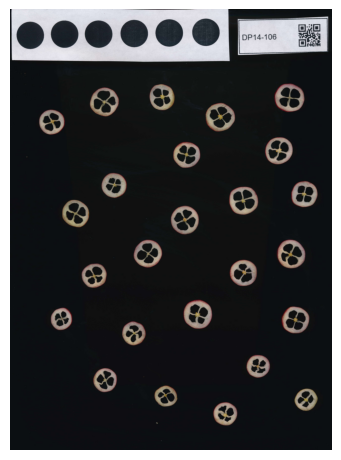


LABEL DETECTION:
    > QR Code detected: DP14-106

REFERENCE SIZE:
Image dimensions:
    - Width:  2,552 pixels
    - Length: 3,504 pixels

Processing 1 high-confidence (>=0.6) size reference box(es):
  - Ref 1: 1927x298 px, conf: 0.774

Total circles detected: 6
  - Diameter range (mean ± 2): 218.00 px to 218.00 px
  - Total circles after removing outliers (std < 2): 6
  - Mean diameter of filtered circles: 218.00 px

 >>> Estimated px/cm density: 128.24 px/cm (Reference diameter: 1.7 cm)



In [186]:
from traitly.internal_structure import FruitAnalyzer
#path_folder = '/Users/alejandra/Downloads/IMG_20250726_0004.jpg' #orange
path_folder = '../tests/sample_data/img_test_1.jpg' 
analyzer = FruitAnalyzer(path_folder)
analyzer.read_image(plot = True)
analyzer.setup_measurements(diameter_cm = 1.7, gpu = True, detect_label = False)



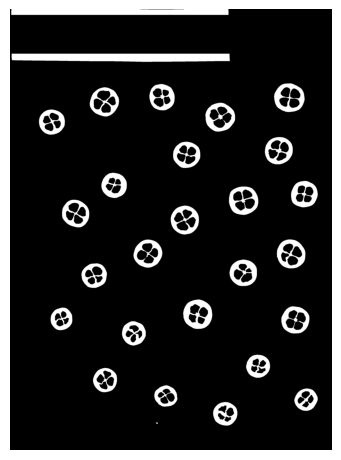

In [187]:
analyzer.create_mask(plot = True, roi_expansion=10, locules_filled = True, canny_min = 50, canny_max = 300, n_blur = 1)

In [188]:
analyzer.find_fruits()

Total detected objects: 124
Detected fruits after filtering: 25


In [162]:
from typing import List, Optional, Tuple
import cv2
import numpy as np

def get_inner_pericarp_area(
    locules: List[int], 
    contours: List[np.ndarray], 
    px_per_cm: Optional[float] = None, 
    img: Optional[np.ndarray] = None,
    draw_inner_pericarp: Optional[bool] = False, 
    use_ellipse: bool = False, 
    contour_thickness: int = 2, 
    contour_color: Tuple[int, int, int] = (0, 240, 240)
) -> Tuple[float, float, np.ndarray]:
    if draw_inner_pericarp and img is None:
        raise ValueError("img cannot be None when draw_inner_pericarp=True")

    if not locules:
        return 0.0, 0.0, None

    all_points = np.vstack([contours[i] for i in locules])
    area_px = 0.0

    # máscara binaria (una sola vez)
    if img is not None:
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
    else:
        # si no te pasan img, usa el bounding box de los puntos
        x, y, w, h = cv2.boundingRect(all_points)
        mask = np.zeros((y + h, x + w), dtype=np.uint8)

    hull = cv2.convexHull(all_points)
    epsilon_val = 0.0001 * cv2.arcLength(hull, True)
    smoothed_hull = cv2.approxPolyDP(hull, epsilon_val, True)
    # Draw yellow line around all the locules
    cv2.drawContours(img, [smoothed_hull], -1, contour_color, contour_thickness)
    
    
    if draw_inner_pericarp and img is not None:
        cv2.drawContours(mask, [smoothed_hull], -1, 255, -1)

    area_px = cv2.contourArea(smoothed_hull)

    if px_per_cm is not None and not isinstance(px_per_cm, dict) and isinstance(px_per_cm, (int, float)) and px_per_cm > 0:
        area_cm2 = area_px / (px_per_cm ** 2)
    else:
        area_cm2 = np.nan
    if draw_inner_pericarp:
        return area_cm2, area_px, mask 
    else:
        return area_cm2, area_px



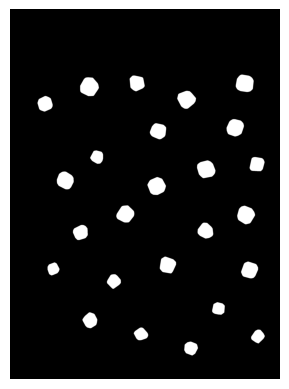

In [163]:
import numpy as np
import matplotlib.pyplot as plt

img = analyzer.img.copy()

# Empty mask using the image dimesnions
combined = np.zeros(img.shape[:2], dtype=np.uint8)

for fruit_id, locs in analyzer.fruit_locus_map.items():
    _, _, mask = get_inner_pericarp_area(
        locules = locs,
        contours = analyzer.contours,
        img = img,
        draw_inner_pericarp = True
    )

    if mask is not None:
        combined = np.maximum(combined, mask)   # OR binario

plt.imshow(combined, cmap="gray")
plt.axis("off")
plt.show()


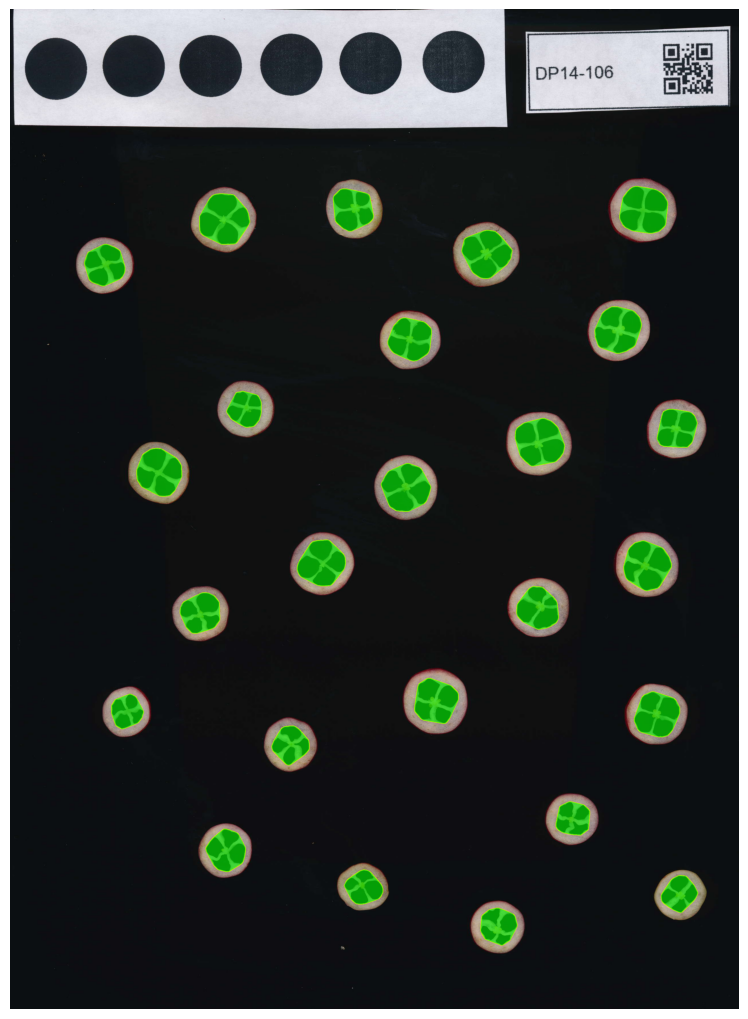

In [ ]:
# Mask for core area
m = (combined > 0).astype(np.uint8)

green = np.zeros_like(img)
green[:, :, 1] = 255

overlay = cv2.addWeighted(green, 0.6, img, 0.4, 0)
result = img.copy()
result[m == 1] = overlay[m == 1]

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig('/Users/alejandra/Documents/color/cranberry_filled.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


In [ ]:
# Mask of only inner_flesh

img = analyzer.img
h, w = img.shape[:2]

# máscara final: solo pericarpio interno sin loculos
inner_without_locules = np.zeros((h, w), dtype=np.uint8)

for fruit_id, locule_idxs in analyzer.fruit_locus_map.items():

    # 1) máscara del inner pericarp de ESTE fruto
    _, _, inner_mask = get_inner_pericarp_area(
        locules=locule_idxs,
        contours=analyzer.contours,
        img=img,
        draw_inner_pericarp=True   # solo queremos la máscara
    )

    # 2) máscara de loculos de ESTE fruto
    locule_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(
        locule_mask,
        [analyzer.contours[i] for i in locule_idxs],
        -1,
        255,
        thickness=-1
    )

    # 3) pericarpio interno SIN loculos (anillo)
    fruit_ring = cv2.bitwise_and(inner_mask, cv2.bitwise_not(locule_mask))

    # 4) acumular en la máscara global
    inner_without_locules = cv2.bitwise_or(inner_without_locules, fruit_ring)


In [189]:
#### Working on axes
from traitly.internal_structure.geometry import calculate_axes
img = analyzer.img.copy()

for fruit_id, locule_idxs in analyzer.fruit_locus_map.items():
    fruit_contour = analyzer.contours[fruit_id]
    max_dist_cm, min_dist_cm, max_dist_px, min_dist_px = calculate_axes(img = img, 
                                                                        fruit_contour = fruit_contour, 
                                                                        draw_axes = True)


In [ ]:
plt.figure(figsize= (8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout(pad=0)
#plt.savefig('/Users/alejandra/Documents/color/cranberry_axes.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


In [193]:
#### Working on boxes
from traitly.internal_structure.geometry import rotate_box
img = analyzer.img.copy()

for fruit_id, locule_idxs in analyzer.fruit_locus_map.items():
    fruit_contour = analyzer.contours[fruit_id]

    box_length_cm, box_width_cm, box_length_px, box_width_px = rotate_box(img = img, 
                                                                          contour = fruit_contour,
                                                                          draw_box = True)


In [ ]:
plt.figure(figsize= (20,20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout(pad=0)
#plt.savefig('/Users/alejandra/Documents/color/cranberry_boxes.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


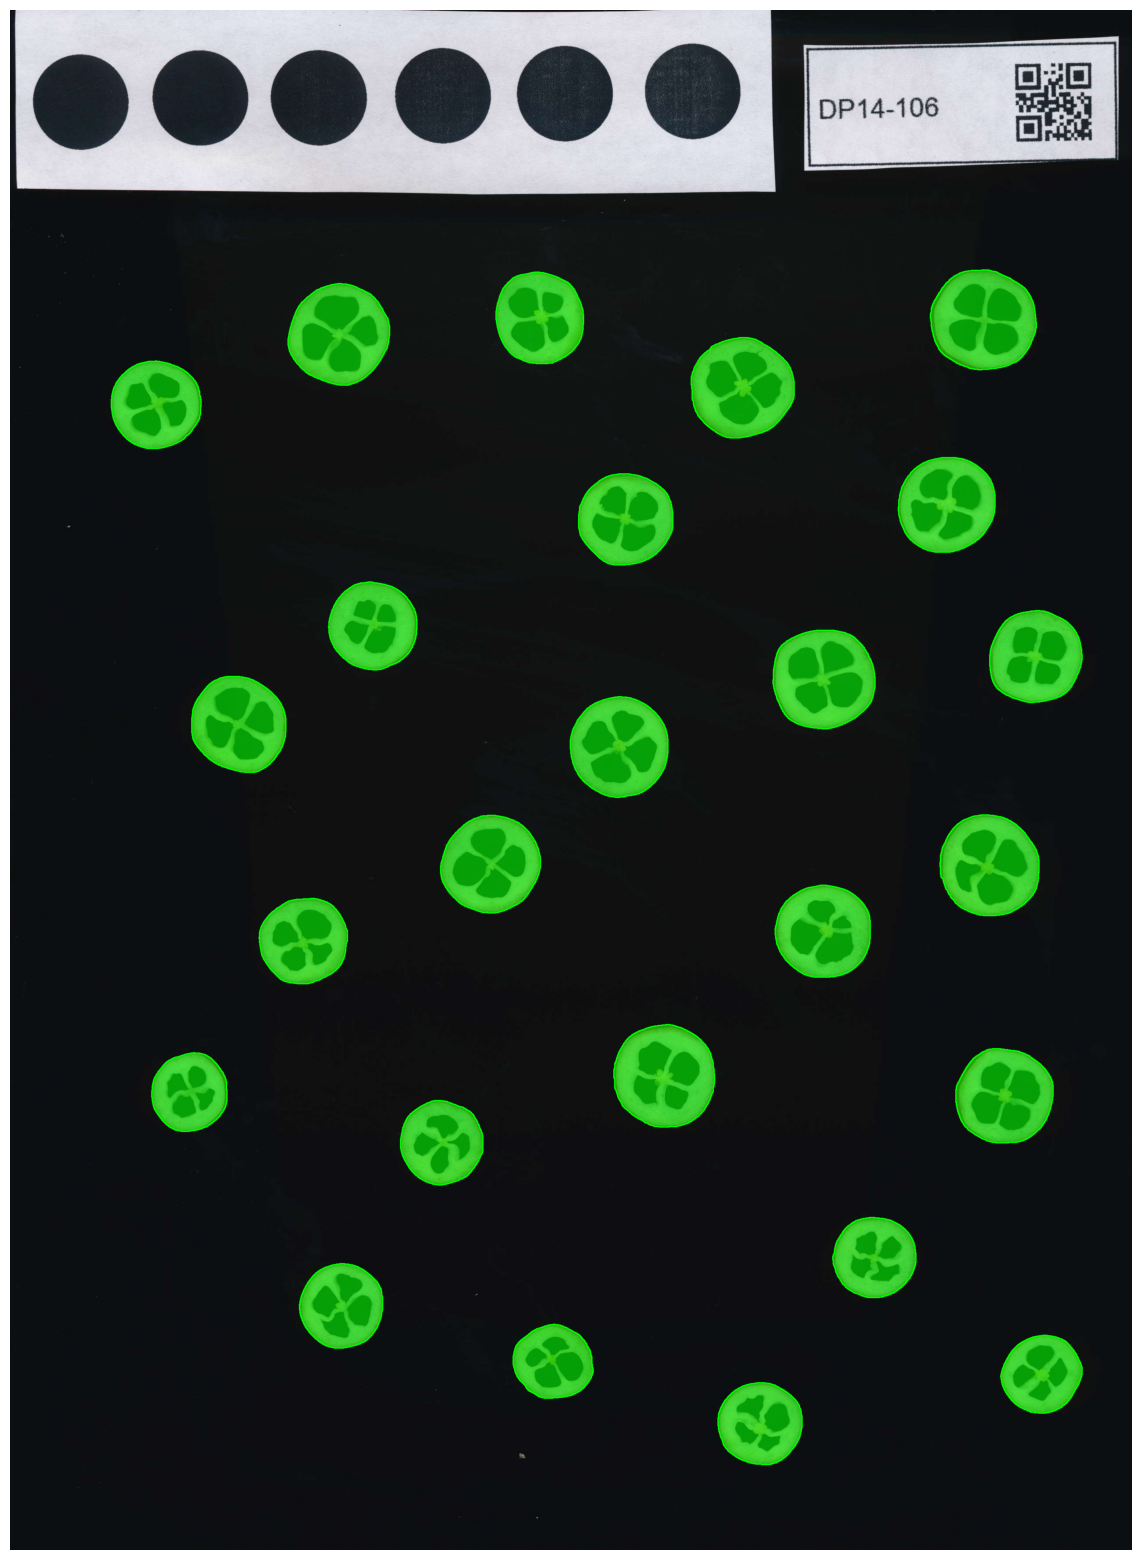

In [ ]:
from traitly.internal_structure.processing import (
    precalculate_locules_data, 
    get_fruit_contour, 
    calculate_fruit_centroids
)
from traitly.internal_structure.mask import merge_locules_func

# PASO 1: Crear imágenes base
img = analyzer.img.copy()
overlay = img.copy()  # Copia para el relleno translúcido

# PASO 2: Procesar cada fruto y rellenar lóculos en overlay
for fruit_id, locules in analyzer.fruit_locus_map.items():
    # Obtener el contorno del fruto
    fruit_contour = analyzer.contours[fruit_id]
    
    # Calcular centroide del fruto
    fruit_centroids = calculate_fruit_centroids([fruit_contour])
    fruit_centroid = fruit_centroids[0]
    
    # Precalcular datos de lóculos
    locules_data = precalculate_locules_data(
        contours=analyzer.contours,
        locules=locules,
        centroid=fruit_centroid
    )
    
    # Rellenar los lóculos en el overlay (verde)
    for locule_id in locules:
        locule_contour = analyzer.contours[locule_id]
        if len(locule_contour) > 0:
            cv2.drawContours(
                overlay, 
                [locule_contour], 
                -1, 
                (0, 255, 0),  # Verde
                cv2.FILLED
            )
    
    # Opcional: contorno del fruto en el overlay
    # cv2.drawContours(overlay, [fruit_contour], -1, (0, 0, 255), 2)

# PASO 3: Mezclar overlay con imagen original (relleno translúcido)
alpha = 0.6  # 70% overlay, 30% original
img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

# PASO 4: AHORA dibujar contornos rosa (opacos) sobre la mezcla
for fruit_id, locules in analyzer.fruit_locus_map.items():
    for locule_id in locules:
        locule_contour = analyzer.contours[fruit_id]
        if len(locule_contour) > 0:
            # Contorno rosa opaco
            cv2.drawContours(
                img,  # Sobre la imagen YA mezclada
                [locule_contour], 
                -1, 
                (255, 0, 255),  # Rosa/Magenta
                2  # Grosor
            )

# Mostrar resultado
plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
#plt.savefig('/Users/alejandra/Documents/color/cranberry_locules.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


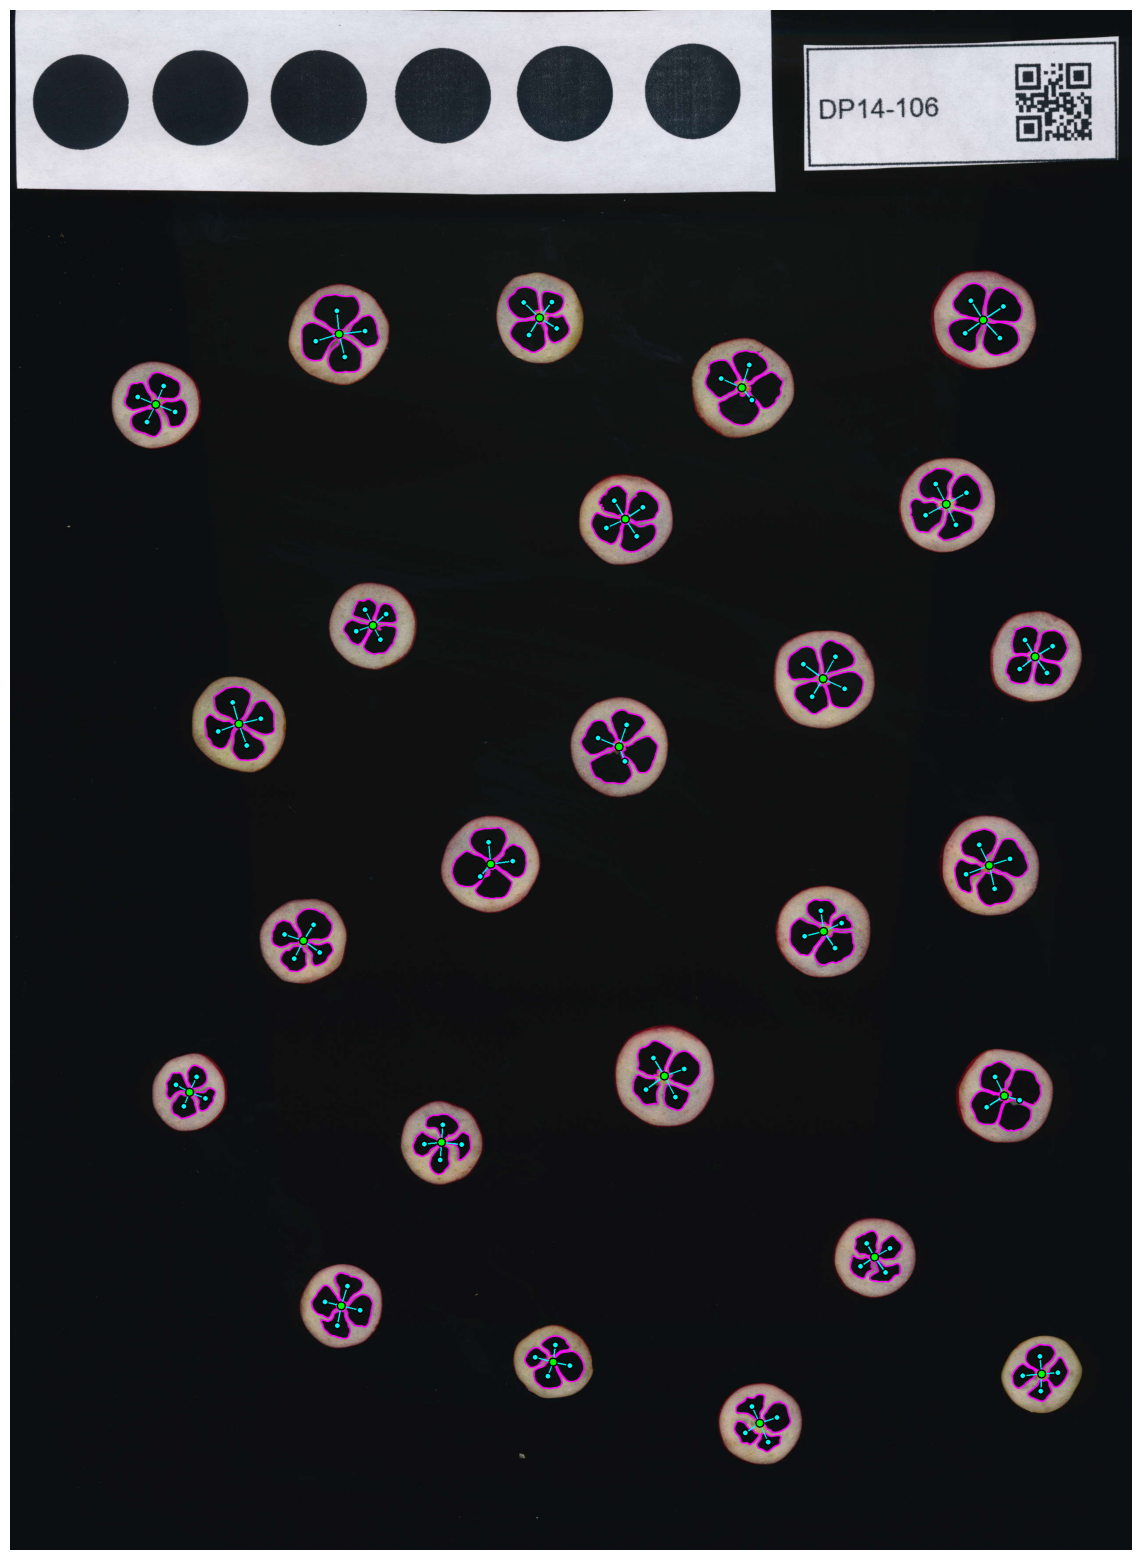

In [ ]:
from traitly.internal_structure.processing import (
    precalculate_locules_data, 
    get_fruit_contour, 
    calculate_fruit_centroids
)
from traitly.internal_structure.mask import merge_locules_func

# Crear imagen base
img = analyzer.img.copy()

# PASO 1: Dibujar contornos rosa de los lóculos
for fruit_id, locules in analyzer.fruit_locus_map.items():
    for locule_id in locules:
        locule_contour = analyzer.contours[locule_id]
        if len(locule_contour) > 0:
            # Contorno rosa
            cv2.drawContours(
                img,
                [locule_contour], 
                -1, 
                (255, 0, 255),  # Rosa/Magenta
                2
            )

# PASO 2: Dibujar centroides y líneas
for fruit_id, locules in analyzer.fruit_locus_map.items():
    # Obtener el contorno del fruto
    fruit_contour = analyzer.contours[fruit_id]
    
    # Calcular centroide del fruto
    M_fruit = cv2.moments(fruit_contour)
    if M_fruit["m00"] != 0:
        fruit_cx = int(M_fruit["m10"] / M_fruit["m00"])
        fruit_cy = int(M_fruit["m01"] / M_fruit["m00"])
        
        # Procesar centroides de lóculos (primero líneas, luego puntos)
        for locule_id in locules:
            locule_contour = analyzer.contours[locule_id]
            if len(locule_contour) > 0:
                M_locule = cv2.moments(locule_contour)
                if M_locule["m00"] != 0:
                    locule_cx = int(M_locule["m10"] / M_locule["m00"])
                    locule_cy = int(M_locule["m01"] / M_locule["m00"])
                    
                    # Dibujar línea desde centroide del fruto al centroide del lóculo
                    cv2.line(
                        img, 
                        (fruit_cx, fruit_cy),      # Inicio (centroide fruto)
                        (locule_cx, locule_cy),    # Fin (centroide lóculo)
                        (255, 255, 0),             # Cyan para línea
                        2                          # Grosor
                    )
                    
                    # Dibujar centroide del lóculo en CYAN
                    cv2.circle(img, (locule_cx, locule_cy), 6, (255, 255, 0), -1)  # Cyan, relleno
                    cv2.circle(img, (locule_cx, locule_cy), 7, (0, 0, 0), 2)       # Borde negro
        
        # Dibujar centroide del fruto en VERDE (al final para que quede encima)
        cv2.circle(img, (fruit_cx, fruit_cy), 8, (0, 255, 0), -1)  # Verde, relleno
        cv2.circle(img, (fruit_cx, fruit_cy), 9, (0, 0, 0), 2)     # Borde negro

# Mostrar resultado
plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
#plt.savefig('/Users/alejandra/Documents/color/cranberry_symmetry.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()